In [1]:

import warnings
warnings.filterwarnings('ignore',category=FutureWarning)
import pandas as pd
import os
import seaborn as sns
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import mysql.connector  

1. DATABASE OPERATIONS

In [ ]:
##CREATE TABLE WITH FIELD NAMES AND DATA TYPES IN THE DATABASE MYSQL
##CREATE TABLE IF NOT EXISTS credit_default_raw ( ID INT, LIMIT_BAL INT, SEX TINYINT, EDUCATION TINYINT, MARRIAGE TINYINT, AGE INT, PAY_0 TINYINT, PAY_2 TINYINT, PAY_3 TINYINT, PAY_4 TINYINT, PAY_5 TINYINT, PAY_6 TINYINT, BILL_AMT1 BIGINT, BILL_AMT2 BIGINT, BILL_AMT3 BIGINT, BILL_AMT4 BIGINT, BILL_AMT5 BIGINT, BILL_AMT6 BIGINT, PAY_AMT1 BIGINT, PAY_AMT2 BIGINT, PAY_AMT3 BIGINT, PAY_AMT4 BIGINT, PAY_AMT5 BIGINT, PAY_AMT6 BIGINT, default payment next month TINYINT );

#to see databases;
#  mysql>show databases;
# #use database
# mysql>use database(ml_practice);
# #to see tables 
# mysql> show tables; 
# credit_default_raw(created new table in DB)

In [10]:
mydb = mysql.connector.connect(
    host="localhost",               #hostname
    user="root",                   # the user who has privilege to the db
    password="Jaanu@0925",         #password for user
    database="ML_Practice"         #database name (case-sensitive)
)

In [3]:
#insert data into the table credit_default_raw by using python
import pandas as pd
import mysql.connector



# load CSV correctly 
df1 = pd.read_csv("default of credit card clients.csv")

# drop unnamed index column if it exists
if "Unnamed: 0" in df1.columns:
    df1 = df1.drop(columns=["Unnamed: 0"])

print("Columns in CSV:", df1.columns)
print("Shape:", df1.shape)  # should be (30000, 26)

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Jaanu@0925",
    database="ML_Practice"
)
cursor = conn.cursor()
##if we run this load csv after restaring kernel, again new set of data is added into the table(duplication of rows)
## to avoid duplication of rows , need to add this
cursor.execute("TRUNCATE TABLE credit_default_raw")
cols = ",".join([f"`{c}`" for c in df1.columns])
placeholders = ",".join(["%s"] * len(df1.columns))

sql = f"INSERT INTO credit_default_raw ({cols}) VALUES ({placeholders})"

for _, row in df1.iterrows():
    cursor.execute(sql, tuple(row))
conn.commit()
conn.close()



Columns in CSV: Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')
Shape: (30000, 25)


In [4]:
df1.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [6]:
df1.shape

(30000, 25)

In [8]:
print(mydb)

In [11]:
#define cursor object
cursor=mydb.cursor()
#defining query to see all the database available in the mysql server
query='show tables'
#execute query
cursor.execute(query)
for i in cursor:
    print(i)
    

('credit_default_raw',)


In [12]:
#fetch all databases
result=(cursor.fetchall())
#iterate through all data bases
for i in result:
    print(i)

In [13]:
#define the query to navigate to the table we want
query = "SELECT * FROM credit_default_raw WHERE ID=20"
cursor.execute(query)

# consume result
result = cursor.fetchall()   # or cursor.fetchone()
print(result)

[(20, 180000, 2, 1, 2, 29, 1, -2, -2, -2, -2, -2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)]


In [14]:
query='Select * from credit_default_raw'
data_frame=pd.read_sql(query,mydb)
print(data_frame)

C:\Users\life\AppData\Local\Temp\ipykernel_11944\1535728332.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_frame=pd.read_sql(query,mydb)


          ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
0          1      20000    2          2         1   24      2      2     -1   
1          2     120000    2          2         2   26     -1      2      0   
2          3      90000    2          2         2   34      0      0      0   
3          4      50000    2          2         1   37      0      0      0   
4          5      50000    1          2         1   57     -1      0     -1   
...      ...        ...  ...        ...       ...  ...    ...    ...    ...   
29995  29996     220000    1          3         1   39      0      0      0   
29996  29997     150000    1          3         2   43     -1     -1     -1   
29997  29998      30000    1          2         2   37      4      3      2   
29998  29999      80000    1          3         1   41      1     -1      0   
29999  30000      50000    1          2         1   46      0      0      0   

       PAY_4  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6 

In [15]:
df=pd.read_sql_query("select * from credit_default_raw",mydb)
df

C:\Users\life\AppData\Local\Temp\ipykernel_11944\1372963067.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query("select * from credit_default_raw",mydb)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [16]:
df.shape

(30000, 25)

In [17]:
columns = df.columns
for i in columns:
 print(i)
 

ID
LIMIT_BAL
SEX
EDUCATION
MARRIAGE
AGE
PAY_0
PAY_2
PAY_3
PAY_4
PAY_5
PAY_6
BILL_AMT1
BILL_AMT2
BILL_AMT3
BILL_AMT4
BILL_AMT5
BILL_AMT6
PAY_AMT1
PAY_AMT2
PAY_AMT3
PAY_AMT4
PAY_AMT5
PAY_AMT6
default payment next month


In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [19]:
#save df into csv file
data=df.to_csv("data.csv",index=False)
#read data from csv file
data=pd.read_csv("data.csv")
data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


2. Plotting BAR PLOTS

In [20]:
data.LIMIT_BAL.value_counts(ascending=False)

LIMIT_BAL
50000      3365
20000      1976
30000      1610
80000      1567
200000     1528
           ... 
800000        2
1000000       1
327680        1
760000        1
690000        1
Name: count, Length: 81, dtype: int64

<Axes: title={'center': 'unique blalances'}, xlabel='LIMIT_BAL'>

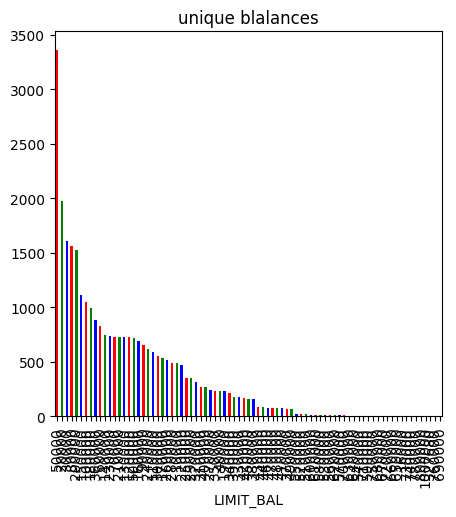

In [21]:
data['LIMIT_BAL'].value_counts(ascending=False).plot(kind='bar',color=['red','green','blue'],title='unique blalances',figsize=(5,5))

In [22]:
data['SEX'].value_counts()

SEX
2    18112
1    11888
Name: count, dtype: int64

<Axes: title={'center': 'ratio of sex'}, xlabel='SEX'>

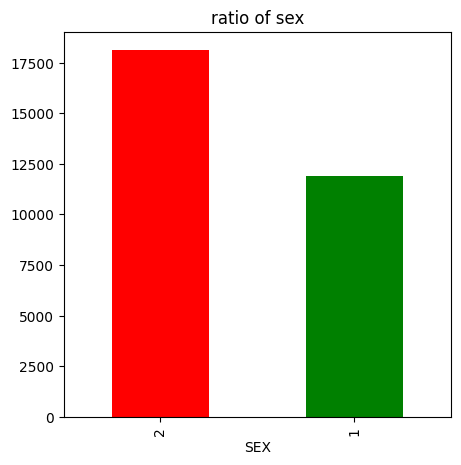

In [23]:
data['SEX'].value_counts().plot(kind='bar',color=['red','green'],figsize=(5,5),title='ratio of sex')

In [24]:
data['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [25]:
data['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

<Axes: title={'center': 'marriage'}, xlabel='MARRIAGE'>

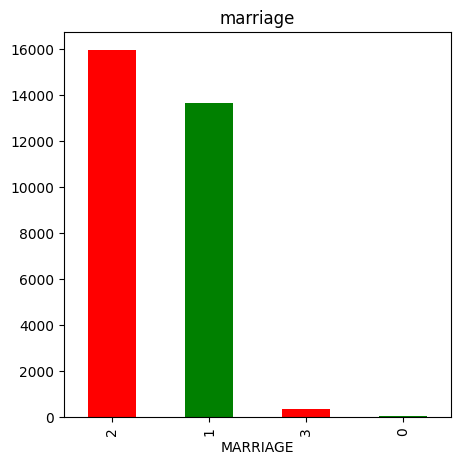

In [26]:
data["MARRIAGE"].value_counts().plot(kind='bar',color=['r','g'],title='marriage',figsize=(5,5))

In [27]:
#finding duplicate data
data['ID'].nunique()

30000

In [28]:
total_rows = len(data)
unique_ids = data['ID'].nunique()
duplicates = total_rows - unique_ids

print(f"Total rows: {total_rows}")
print(f"Unique IDs: {unique_ids}")
print(f"Duplicate IDs: {duplicates}")

Total rows: 30000
Unique IDs: 30000
Duplicate IDs: 0


In [29]:
#all the values in Id number are unique values so
#they are not much important in model building.
## Finding null values

data.isnull().sum()

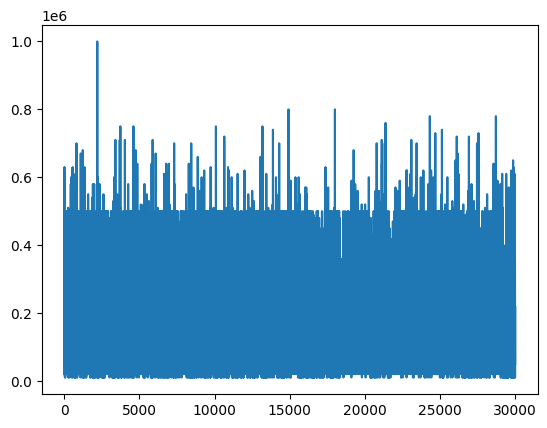

In [30]:
plt.plot(data["LIMIT_BAL"])

In [31]:
##BOX PLOT

box_plot_data=data['LIMIT_BAL']
plt.boxplot(box_plot_data,notch='True',patch_artist=True)
plt.show()

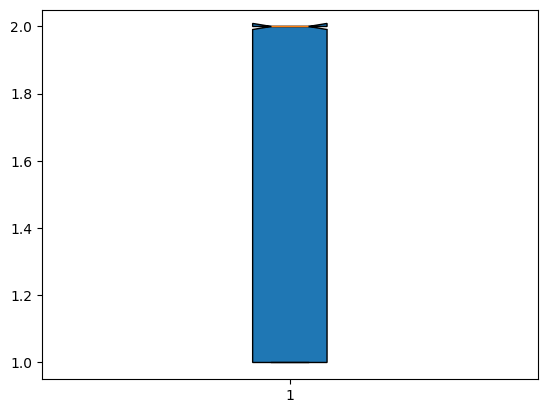

In [32]:
box_plot_data=data['SEX']
plt.boxplot(box_plot_data,notch='True',patch_artist=True)
plt.show()

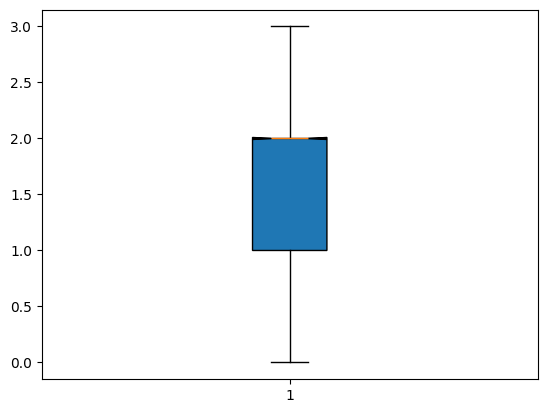

In [33]:
box_plot_data=data['MARRIAGE']
plt.boxplot(box_plot_data,notch='True',patch_artist=True)
plt.show()

In [ ]:
#3.Finding Outliers
#Here we are finding outliers using boxplot

SyntaxError: invalid decimal literal (323296169.py, line 1)

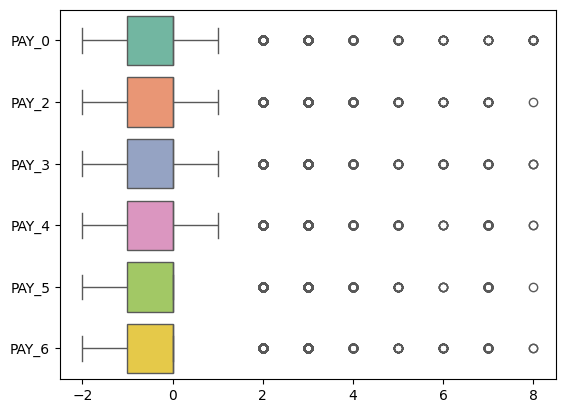

In [35]:
df_1 = data[['PAY_0', 'PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']]
df_2 = data[['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']]
df_3 = data[['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']]

ax = sns.boxplot(data=df_1, orient="h", palette="Set2")

#HISTOGRAM

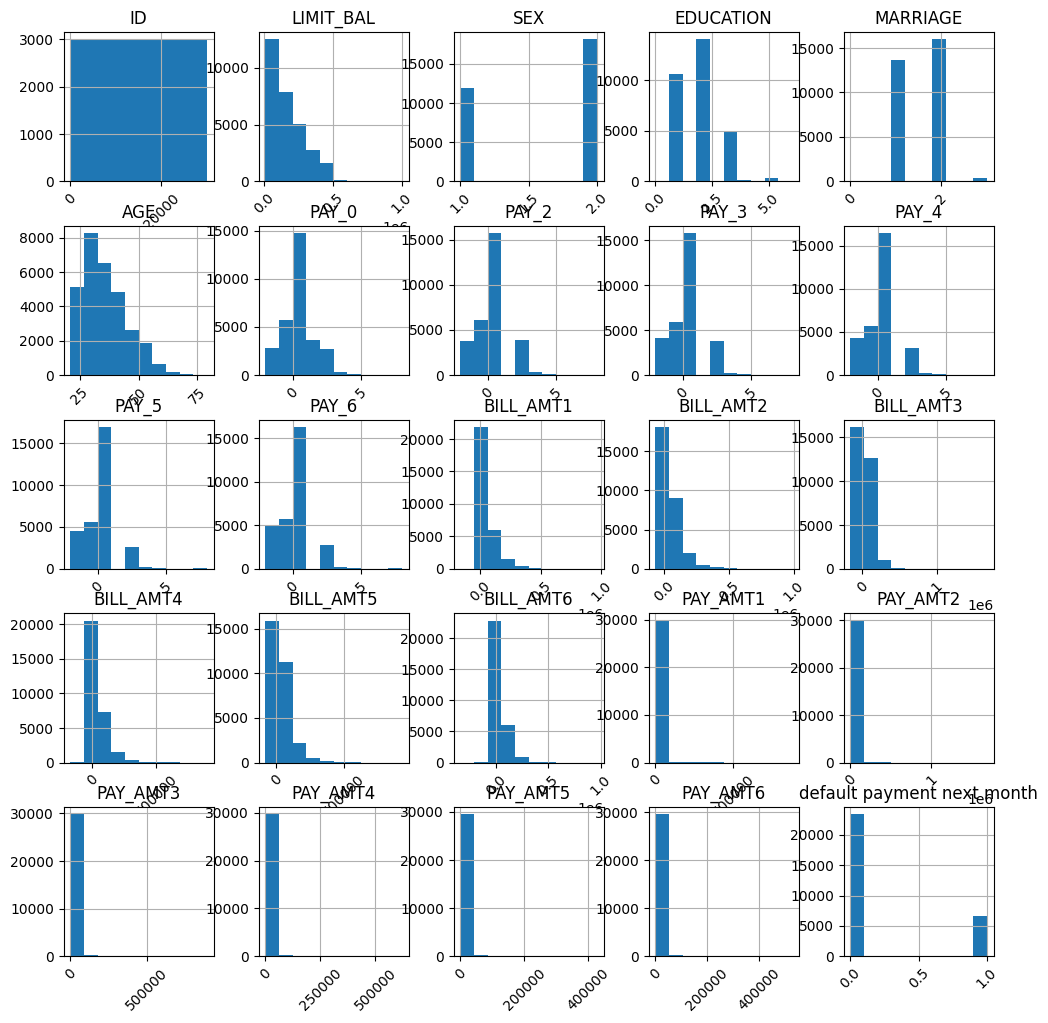

In [36]:
#Histogram
data.hist(figsize=(12,12), xrot=45)
plt.show()

In [37]:
X=df.drop('default payment next month',axis=1)
y=df['default payment next month']

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0)

X_train.shape, X_test.shape
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (21000, 24)
Test shape: (9000, 24)


In [40]:
#4.BUILD THE MODEL USING ALGORITHMS

In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier

In [43]:
#i. LOGISTIC REGRESSION ALGORITHM
X_train, X_test, y_train, y_test, = train_test_split(X,
                                                  y,
                                                  test_size = .3,
                                                  random_state=0)
clf = LogisticRegression(max_iter=500, solver='saga')  # good for large datasets
trained_model = clf.fit(X_train, y_train)
trained_model.fit(X_train, y_train)
y_pred = trained_model.predict(X_test)

Train_Accuracy= accuracy_score(y_train, trained_model.predict(X_train))
Test_Accuracy= accuracy_score(y_test, y_pred)
Confusion_Matrix= confusion_matrix(y_test, y_pred)
print("Train accuracy:",Train_Accuracy)
print("Test accuracy:",Test_Accuracy)
print(Confusion_Matrix)
print(accuracy_score(y_test, y_pred))

Train accuracy: 0.7762380952380953
Test accuracy: 0.7845555555555556
[[7060    0]
 [1939    1]]
0.7845555555555556


In [44]:
#Our model showed a accuracy of 77 percent without any outlier treatment .
#In order to improve our model we can check for correlation of features

In [45]:
#checking correlation
X_train.corr()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
ID,1.000000,0.030391,0.016759,0.034518,-0.033774,0.022768,-0.030399,-0.012601,-0.022912,-0.007375,...,0.025996,0.041812,0.016636,0.016038,0.016326,0.010308,0.043374,0.008823,-0.004063,0.005704
LIMIT_BAL,0.030391,1.000000,0.026729,-0.215178,-0.110903,0.147624,-0.268271,-0.295177,-0.285572,-0.267489,...,0.281839,0.288848,0.290803,0.285093,0.188021,0.178122,0.202081,0.200656,0.215698,0.221848
SEX,0.016759,0.026729,1.000000,0.014225,-0.034579,-0.084932,-0.065389,-0.075153,-0.070457,-0.060587,...,-0.026960,-0.025236,-0.018538,-0.018343,-0.003899,-0.002292,-0.011307,-0.001476,-0.002539,-0.003660
EDUCATION,0.034518,-0.215178,0.014225,1.000000,-0.142816,0.176723,0.107096,0.123027,0.114751,0.106927,...,0.012254,0.000228,-0.007935,-0.009493,-0.036566,-0.036294,-0.037621,-0.043597,-0.042287,-0.036042
MARRIAGE,-0.033774,-0.110903,-0.034579,-0.142816,1.000000,-0.412603,0.016384,0.018425,0.027696,0.031648,...,-0.029844,-0.027946,-0.030112,-0.025313,-0.005654,-0.004304,-0.000490,-0.009689,-0.000616,-0.006177
AGE,0.022768,0.147624,-0.084932,0.176723,-0.412603,1.000000,-0.036249,-0.049272,-0.053959,-0.053472,...,0.053196,0.052643,0.051006,0.048441,0.025856,0.016954,0.033150,0.015962,0.020478,0.020046
PAY_0,-0.030399,-0.268271,-0.065389,0.107096,0.016384,-0.036249,1.000000,0.678245,0.581280,0.538772,...,0.179444,0.180613,0.181751,0.178323,-0.077774,-0.073797,-0.076510,-0.065187,-0.055092,-0.059660
PAY_2,-0.012601,-0.295177,-0.075153,0.123027,0.018425,-0.049272,0.678245,1.000000,0.763802,0.659024,...,0.221788,0.222653,0.221372,0.219875,-0.082482,-0.060762,-0.060202,-0.049971,-0.035097,-0.039727
PAY_3,-0.022912,-0.285572,-0.070457,0.114751,0.027696,-0.053959,0.581280,0.763802,1.000000,0.780698,...,0.224452,0.225280,0.223147,0.219374,0.000249,-0.065734,-0.056435,-0.048793,-0.035492,-0.035782
PAY_4,-0.007375,-0.267489,-0.060587,0.106927,0.031648,-0.053472,0.538772,0.659024,0.780698,1.000000,...,0.242585,0.245452,0.242168,0.238238,-0.009191,-0.002280,-0.070746,-0.047106,-0.032781,-0.024157


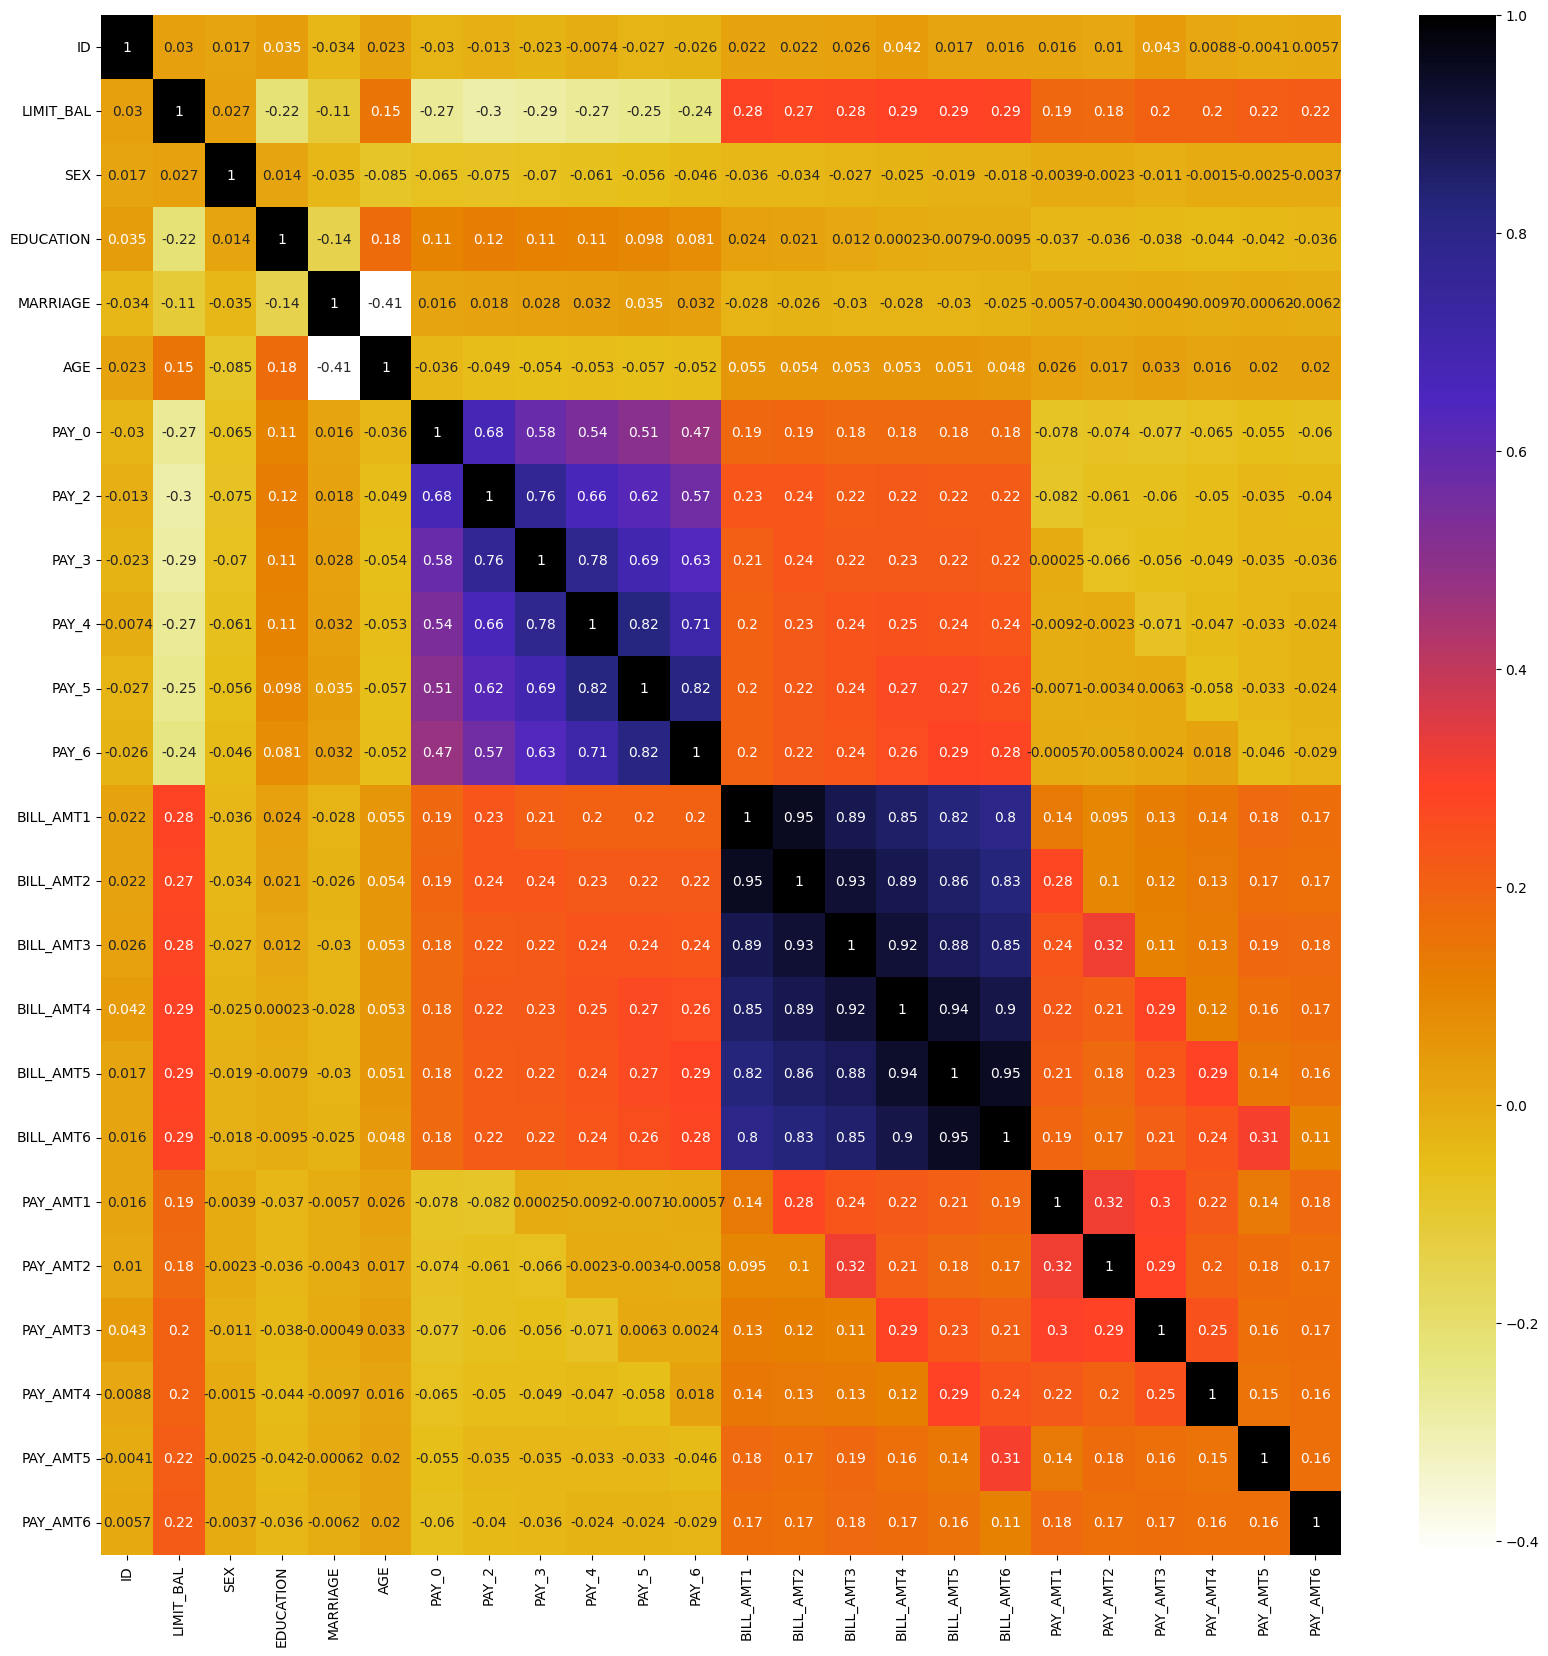

In [46]:
import seaborn as sns
#Using Pearson Correlation
plt.figure(figsize=(20,20))
cor = X_train.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
plt.show()

In [47]:
# with the following function we can select highly correlated features
# it will remove the first feature that is correlated with anything other feature

def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [48]:
corr_features = correlation(X_train, 0.8)
len(set(corr_features))

7

In [49]:
corr_features

{'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_5',
 'PAY_6'}

In [50]:
data1=data.drop(corr_features,axis=1)

In [51]:
X=data1.drop('default payment next month',axis=1)
y=data1['default payment next month']

In [52]:
X.shape

(30000, 17)

In [53]:
y.shape

(30000,)

In [55]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=1
)
# Train the model
clf = LogisticRegression(random_state=0)
trained_model = clf.fit(X_train, y_train)

# Predict
y_pred = trained_model.predict(X_test)

# Evaluate
Train_Accuracy = accuracy_score(y_train, trained_model.predict(X_train))
Test_Accuracy = accuracy_score(y_test, y_pred)
Confusion_Matrix = confusion_matrix(y_test, y_pred)

print("Train accuracy:",Train_Accuracy)
print("Test accuracy:",Test_Accuracy)
print(Confusion_Matrix)
print(accuracy_score(y_test, y_pred))

Train accuracy: 0.7788627450980392
Test accuracy: 0.7784444444444445
[[3503    0]
 [ 997    0]]
0.7784444444444445


c:\Users\life\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [56]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[3503    0]
 [ 997    0]]


0.7784444444444445

## Standaradistion
#AS we have different scales of data we can convert our data using standar scalar.

In [57]:
X=data.drop('default payment next month',axis=1)
y=data['default payment next month']

In [58]:
X_train, X_test, y_train, y_test, = train_test_split(X,
                                                  y,
                                                  test_size = .15,
                                                  random_state=0)

In [59]:
from sklearn import preprocessing
sc= preprocessing.StandardScaler()
scaler_train=sc.fit_transform(X_train)
scaler_train

array([[ 0.20700646, -0.90748654, -1.22815358, ..., -0.24250691,
        -0.1852927 , -0.29473885],
       [-0.50123933, -0.90748654, -1.22815358, ..., -0.26631859,
        -0.27352764, -0.25885211],
       [-0.19419436, -0.52140242, -1.22815358, ...,  0.07315707,
        -0.15251597, -0.23840174],
       ...,
       [-0.59354898, -0.28975195,  0.81423042, ..., -0.04781138,
        -0.3163996 , -0.01305328],
       [-0.48346972, -0.90748654,  0.81423042, ..., -0.24518095,
        -0.25084615, -0.2665703 ],
       [-1.41429716, -0.21253512,  0.81423042, ..., -0.18151334,
        -0.17218201, -0.18206462]], shape=(25500, 24))

In [60]:
scaler_test=sc.transform(X_test)
scaler_test

array([[-0.78047602, -1.13913701, -1.22815358, ..., -0.20698038,
        -0.3163996 , -0.25845775],
       [-0.48404666, -1.13913701,  0.81423042, ..., -0.30884855,
        -0.25084615, -0.29473885],
       [-0.67224296,  0.48241629,  0.81423042, ..., -0.30884855,
        -0.3163996 , -0.29473885],
       ...,
       [ 1.14244937, -0.67583607, -1.22815358, ..., -0.30547416,
        -0.10479306, -0.29473885],
       [-1.22794705,  1.56345183, -1.22815358, ..., -0.30884855,
        -0.0903713 , -0.29473885],
       [-1.54999234, -0.90748654, -1.22815358, ..., -0.24167923,
        -0.24743737, -0.23716232]], shape=(4500, 24))

In [61]:
clf = LogisticRegression(random_state = 0)
trained_model = clf.fit(scaler_train, y_train)
trained_model.fit(scaler_train, y_train)
y_pred = trained_model.predict(scaler_test)

Train_Accuracy= accuracy_score(y_train, trained_model.predict(scaler_train))
Test_Accuracy= accuracy_score(y_test, y_pred)
Confusion_Matrix= confusion_matrix(y_test, y_pred)

In [62]:
print("Train accuracy:",Train_Accuracy)
print("Test accuracy:",Test_Accuracy)
print(Confusion_Matrix)
print(accuracy_score(y_test, y_pred))

Train accuracy: 0.8088235294117647
Test accuracy: 0.8175555555555556
[[3452   77]
 [ 744  227]]
0.8175555555555556


In [63]:
##DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=0)

# Train
trained_model = clf.fit(scaler_train, y_train)

# Predict
y_pred = trained_model.predict(scaler_test)

# Evaluation
Train_Accuracy = accuracy_score(y_train, trained_model.predict(scaler_train))
Test_Accuracy = accuracy_score(y_test, y_pred)
Confusion_Matrix = confusion_matrix(y_test, y_pred)


In [64]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=1
)
# Train the model
clf = LogisticRegression(random_state=0)
trained_model = clf.fit(X_train, y_train)

# Predict
y_pred = trained_model.predict(X_test)

# Evaluate
Train_Accuracy = accuracy_score(y_train, trained_model.predict(X_train))
Test_Accuracy = accuracy_score(y_test, y_pred)
Confusion_Matrix = confusion_matrix(y_test, y_pred)

print("Train accuracy:",Train_Accuracy)
print("Test accuracy:",Test_Accuracy)
print(Confusion_Matrix)
print(accuracy_score(y_test, y_pred))

Train accuracy: 0.7788627450980392
Test accuracy: 0.7784444444444445
[[3503    0]
 [ 997    0]]
0.7784444444444445


c:\Users\life\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [65]:
##KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=5)  # you can tune n_neighbors
trained_model = clf.fit(scaler_train, y_train)

y_pred = trained_model.predict(scaler_test)

from sklearn.metrics import accuracy_score, confusion_matrix
Train_Accuracy = accuracy_score(y_train, trained_model.predict(scaler_train))
Test_Accuracy = accuracy_score(y_test, y_pred)
Confusion_Matrix = confusion_matrix(y_test, y_pred)



In [66]:
print("Train Accuracy:", Train_Accuracy)
print("Test Accuracy:", Test_Accuracy)
print("Confusion Matrix:\n", Confusion_Matrix)

Train Accuracy: 0.7960392156862746
Test Accuracy: 0.7417777777777778
Confusion Matrix:
 [[3263  240]
 [ 922   75]]


In [67]:
##RandomForestClassifier

# Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=0)  # 100 trees
trained_model = clf.fit(scaler_train, y_train)

# Predictions
y_pred = trained_model.predict(scaler_test)

# Accuracy and confusion matrix
Train_Accuracy = accuracy_score(y_train, trained_model.predict(scaler_train))
Test_Accuracy = accuracy_score(y_test, y_pred)
Confusion_Matrix = confusion_matrix(y_test, y_pred)


In [68]:
print("Train Accuracy:", Train_Accuracy)
print("Test Accuracy:", Test_Accuracy)
print("Confusion Matrix:\n", Confusion_Matrix)

Train Accuracy: 1.0
Test Accuracy: 0.7775555555555556
Confusion Matrix:
 [[3495    8]
 [ 993    4]]


In [69]:
##BaggingClassifier
clf = BaggingClassifier(n_estimators=50, random_state=0)  # 100 trees(tried 100 )
trained_model = clf.fit(scaler_train, y_train)

# Predictions
y_pred = trained_model.predict(scaler_test)

# Accuracy and confusion matrix
Train_Accuracy = accuracy_score(y_train, trained_model.predict(scaler_train))
Test_Accuracy = accuracy_score(y_test, y_pred)
Confusion_Matrix = confusion_matrix(y_test, y_pred)

In [70]:
print("Train Accuracy:", Train_Accuracy)
print("Test Accuracy:", Test_Accuracy)
print("Confusion Matrix:\n", Confusion_Matrix)

Train Accuracy: 0.9993333333333333
Test Accuracy: 0.776
Confusion Matrix:
 [[3482   21]
 [ 987   10]]


In [71]:
##GaussianNB
# Gaussian Naive Bayes
clf = GaussianNB()
trained_model = clf.fit(scaler_train, y_train)

# Predictions
y_pred = trained_model.predict(scaler_test)

# Accuracy and confusion matrix
Train_Accuracy = accuracy_score(y_train, trained_model.predict(scaler_train))
Test_Accuracy = accuracy_score(y_test, y_pred)
Confusion_Matrix = confusion_matrix(y_test, y_pred)


In [72]:
print("Train Accuracy:", Train_Accuracy)
print("Test Accuracy:", Test_Accuracy)
print("Confusion Matrix:\n", Confusion_Matrix)

Train Accuracy: 0.7361176470588235
Test Accuracy: 0.7357777777777778
Confusion Matrix:
 [[3243  260]
 [ 929   68]]
